## Regresión lineal para un proceso VAR

Generación de datos VAR

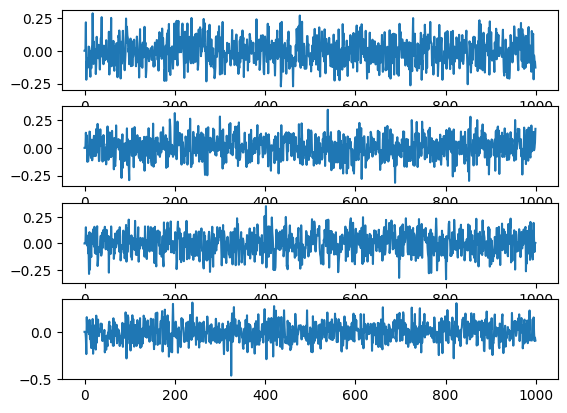

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

def varParams2TransMat( A, p ):
    A = np.abs( A.T )
    N_nds = A.shape[1]
    A2 = np.zeros( (N_nds, N_nds) )
    for n in range(N_nds):
        A2[n, :] = A[:, n].reshape( (N_nds, p) ).sum(axis=1)
    return A2

def X2var( X, p ):
    N, N_nds = X.shape
    Xvar = []
    Yvar = np.zeros( (N-p, N_nds) )
    for j in range( N_nds ):
        Yvar[:, j] = X[p:, j]
        Xvar_tmp = np.zeros( (N-p, p) )
        for i in range( p ):
            Xvar_tmp[:, i] = X[p-i-1: N-i-1, j]
        Xvar.append( Xvar_tmp )
    Xvar = np.hstack( Xvar )
    return Xvar, Yvar

N = 1000
N_nds = 4
p = 3
X = np.zeros( (N, N_nds) )
A = np.zeros( (N_nds, N_nds, p) )

# matriz de conexiones
std_mattrans = 0.2
for j in range( p ):
    A[0, 3, j] = std_mattrans * np.random.randn()
    A[1, 0, j] = std_mattrans * np.random.randn()
    A[2, 1, j] = std_mattrans * np.random.randn()
    A[3, 2, j] = std_mattrans * np.random.randn()

# generación de datos VAR
std_datos = 0.1
for t in range( p, N ):
    X[t, :] = std_datos * np.random.randn( N_nds )
    for j in range( p ):
        X[t, :] = X[t, :] + A[:,:,j] @ X[t-j-1, :]

# visualización de los datos
fig, axs = plt.subplots(nrows = N_nds, ncols = 1)
for nd in range(N_nds):
    axs[ nd ].plot( X[:, nd] )
plt.show()


Matriz de conexiones real

Text(0.5, 1.0, 'matrix de conexiones')

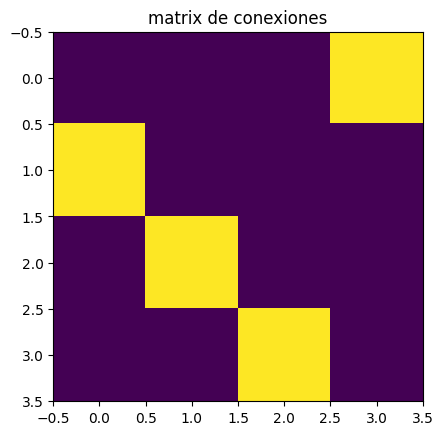

In [2]:
A_ = np.sum( A, axis=2 )
A_[ A_!=0 ] = 1

f, ax = plt.subplots(1,1)
ax.imshow(A_)
ax.set_title('matrix de conexiones')

Solución mediante Ridge regression y Lasso

In [3]:
p = 3
Xvar, Yvar = X2var( X, p )

modelo = Ridge( alpha=0.1 )
A_ridge = modelo.fit( Xvar, Yvar ).coef_
A_ridge = varParams2TransMat(A_ridge, p)

modelo = Lasso( alpha=0.001 )
A_lasso = modelo.fit( Xvar, Yvar ).coef_
A_lasso = varParams2TransMat(A_lasso, p)

Visualización de los resultados

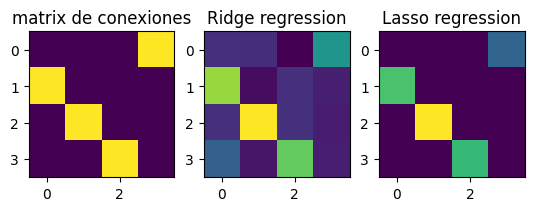

In [4]:
f, ax = plt.subplots(1,3)
ax[0].imshow(A_)
ax[0].set_title('matrix de conexiones')
ax[1].imshow(A_ridge)
ax[1].set_title('Ridge regression')
ax[2].imshow(A_lasso)
ax[2].set_title('Lasso regression')
plt.show()